# cities

In real projects, the hardest part is usually getting data loaded and cleaned.
("Cleaned" means check for nulls, fix wrong types, look for other problems...)
So, to speed us up, I've done some of that. You can copy my code.

Each row is a city. Columns are:
- `name` city name
- `country` country where the city is located
- `subcountry` state, provice, prefecture, etc.
- `geonameid` unique ID number

Project ideas:
- How many of the cities in this table are in China?
- What are all the `subcountry` values for China?
- Find any cities in China with a null `subcountry`.
- Answer the same questions about another country.

In [9]:
from pathlib import Path
import pandas as pd

In [10]:
# Where is the dataset on your computer?
DATA_PATH = Path.cwd().parent / "data" / "cities.csv"
print(f"The dataset is here: {DATA_PATH}")

The dataset is here: /Users/void/code/chengdu/science/data/cities.csv


In [11]:
def cleanstr(values):
    # Convert strings to lowercase without whitespace.
    return [x.lower().replace(' ', '_').strip() for x in values]

In [12]:
# Read raw data.
cities = pd.read_csv(DATA_PATH)
print(f"{len(cities)} rows loaded")

# Normalize column names
cities.columns = cleanstr(cities.columns)

# Use the unique ID that came with the dataset.
cities = cities.set_index('geonameid').sort_index()

cities

33514 rows loaded


,name,country,subcountry
geonameid,,,
490,Lavāsān,"Iran, Islamic Republic of",Tehran
10570,Alvand,"Iran, Islamic Republic of",Qazvin Province
11725,Zīr Āb,"Iran, Islamic Republic of",Mazandaran
14256,Āzādshahr,"Iran, Islamic Republic of",Hamadan Province
18918,Protaras,Cyprus,Ammochostos
...,...,...,...
13607975,Polo Nord,Italy,Piedmont
13607979,Centro,Italy,Piedmont
13608000,Jinshan,China,Shanghai


`NaN` is not a province, prefecture, city, ... It means Not a Number.

pandas uses `numpy.NaN` as a null marker

In [13]:
# Check data types
cities.dtypes

name          str
country       str
subcountry    str
dtype: object

In [14]:
# Count null markers in each column
cities.isnull().sum()

name            0
country         0
subcountry    123
dtype: int64

In [15]:
# Filtering example: Find cities in a specific subcountry.
# In SQL-style databases, we'd write something like this:
"""
SELECT *
FROM cities
WHERE subcountry == 'Sichuan'
"""

# In pandas, it looks like this:
cities.loc[cities['subcountry'] == 'Sichuan']

,name,country,subcountry
geonameid,,,
1783683,Ziyang,China,Sichuan
1783745,Zigong,China,Sichuan
1784450,Gusong,China,Sichuan
1785711,Yunjin,China,Sichuan
1786770,Yibin,China,Sichuan
...,...,...,...
6921777,Shuanglong,China,Sichuan
6929460,Panzhihua,China,Sichuan
6963006,Taifu,China,Sichuan


<Axes: xlabel='country', ylabel='# of cities in table'>

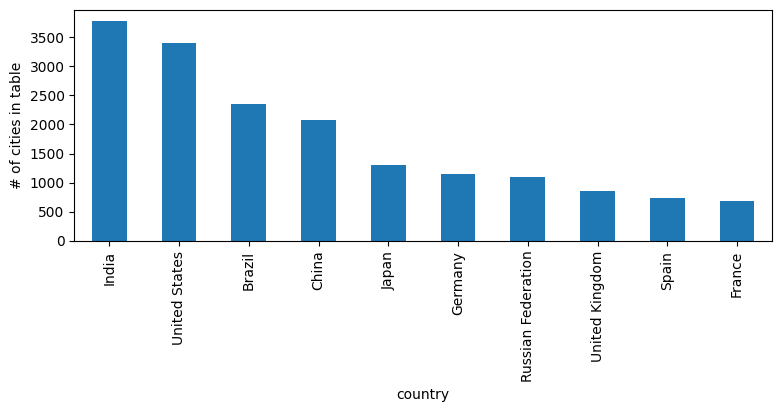

In [16]:
# Example project: Which countries have the most cities?
# In SQL-style databases, we'd write something like this:
"""
SELECT country, COUNT(name) as n_cities
FROM cities
GROUP BY country
ORDER BY n_cities DESC
LIMIT 10
"""

# In pandas, it looks like this:
top10countries = (
    cities
    .groupby('country')
    .count()['name']
    .nlargest(10)
)

# Show a bar chart
top10countries.plot(
    kind='bar',
    ylabel="# of cities in table",
    figsize=(9,3),
)